In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy
import unicodedata
import seaborn as sns

from unidecode import unidecode as _unidecode

In [4]:
nlp = spacy.load("pt_core_news_lg", disable=["ner", "parser"])

def normalize_unidecode(text: str) -> str:
    return _unidecode(text)

def base_clean_pt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\s+', ' ', text.strip()) # remove breaks and normalize spaces
    text = re.sub(r'<[^>]+>', '', text) # remove HTML, URLs, and emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = normalize_unidecode(text) # normalize accents
    text = re.sub(r'\b[a-zA-Z]*\d+[a-zA-Z]*\b', ' ', text) # remove alphanumeric tokens of type Q12, A1, C3
    text = re.sub(r'[^\w\s\-\']', ' ', text) # remove loose punctuation (keep hyphens and apostrophes within words if they exist)
    text = re.sub(r'\s+', ' ', text).strip() # normalize spaces again
    return text.lower()

def spacy_process(texts, lemmatize = False, remove_stopwords = False, batch_size=512):
    cleaned = (base_clean_pt(t) for t in texts)
    results = []

    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        tokens = []
        for tok in doc:
            if tok.is_punct or tok.is_space or tok.like_num or len(tok.text) <= 2:
                continue
            if remove_stopwords and tok.is_stop:
                continue

            token = tok.lemma_ if lemmatize else tok.text
            tokens.append(token.lower())

        results.append(" ".join(tokens))

    return results

def data_preprocessing(df, column_name, sufix=""):
    df[f'UNCLEAN_TEXT{sufix}'] = (
        df[column_name]
        .fillna("")
        .astype(str)
    )

    df[f'BASE_TEXT{sufix}'] = spacy_process(
        df[f'UNCLEAN_TEXT{sufix}'],
        lemmatize=False,
        remove_stopwords=False
    )

    return df

In [5]:
df_1 = pd.read_csv('../data/05_goemotions_1_pt.csv')
df_2 = pd.read_csv('../data/05_goemotions_2_pt.csv')
df_3 = pd.read_csv('../data/05_goemotions_3_pt.csv')

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['author', 'subreddit', 'link_id', 'parent_id', 'created_utc'], inplace=True)

print(df.shape)
df.head(3)

(211225, 33)


,text,id,rater_id,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,texto
0,That game hurt.,eew5j0j,1,False,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Aquele jogo doeu.
1,>sexuality shouldn’t be a grouping category I...,eemcysk,37,True,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...
2,"You do right, if you don't care then fuck 'em!",ed2mah1,37,False,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ..."


In [6]:
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

for c in emotion_cols:
    df[c] = (
        df.groupby('id')[c]
        .transform('sum')
        .ge(2)
        .astype(int)
    )

df['label_sum'] = df[emotion_cols].sum(axis=1)
df = df[df['label_sum'] > 0]

df = (
    df
    .groupby('id', as_index=False)
    .agg(
        {
            **{c: 'max' for c in emotion_cols},
            'text': 'first',
            'texto': 'first'
        }
    )
)

print(df.shape)  # ~54k

(54263, 31)


In [7]:
conflicts = (
    df
    .groupby('id')[emotion_cols]
    .nunique()
    .max(axis=1)
)

(conflicts > 1).sum()

np.int64(0)

In [8]:
df.columns

Index(['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval',
       'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
       'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
       'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride',
       'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral',
       'text', 'texto'],
      dtype='object')

In [9]:
df = data_preprocessing(df, 'texto', '_PT')
df = data_preprocessing(df, 'text', '_EN')

print(df.shape)
df.head(3)

(54263, 35)


,id,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,remorse,sadness,surprise,neutral,text,texto,UNCLEAN_TEXT_PT,BASE_TEXT_PT,UNCLEAN_TEXT_EN,BASE_TEXT_EN
0,eczazk6,0,0,0,0,1,0,0,0,0,...,0,0,0,0,Fast as [NAME] will carry me. Seriously uptown...,Tão rápido quanto [NOME] me carregará. Seriame...,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,Fast as [NAME] will carry me. Seriously uptown...,fast name will carry seriously uptown downtown...
1,eczb07q,0,0,0,0,0,0,0,0,0,...,0,0,0,1,You blew it. They played you like a fiddle.,Você estragou isso. Eles tocaram você como um ...,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,You blew it. They played you like a fiddle.,you blew they played you like fiddle
2,eczb4bm,0,0,0,0,0,0,0,0,0,...,0,0,0,0,TL;DR No more Superbowls for [NAME]. Get ready...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,TL;DR No more Superbowls for [NAME]. Get ready...,more superbowls for name get ready for another...


In [10]:
n_nan = df['BASE_TEXT_PT'].isna().sum()

n_empty = (df['BASE_TEXT_PT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['BASE_TEXT_PT'])
df = df[df['BASE_TEXT_PT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 29
Total problemáticos: 29
(54234, 35)


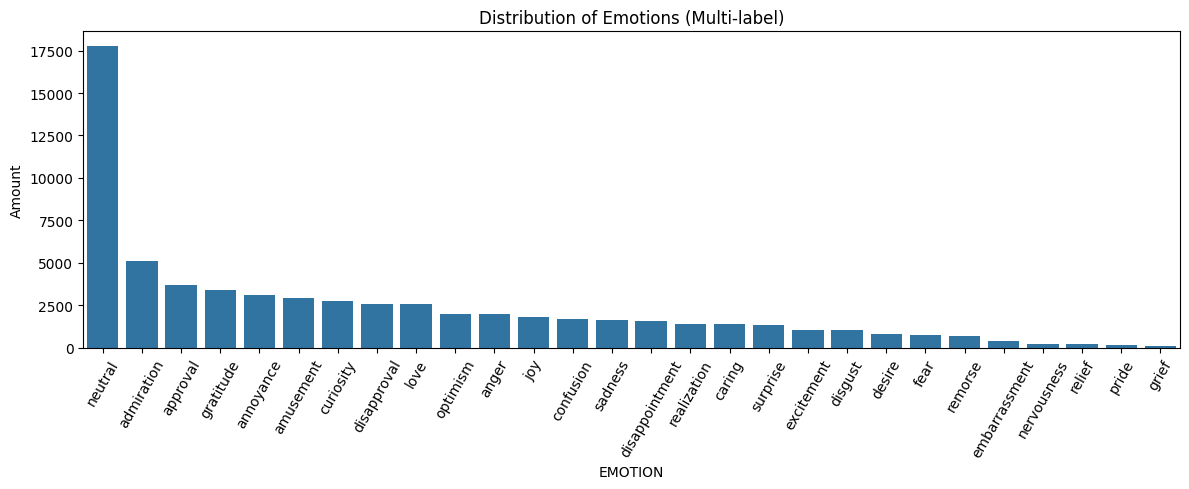

In [11]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

emotion_counts = df[emotions].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values
)

plt.xticks(rotation=60)
plt.ylabel("Amount")
plt.xlabel("EMOTION")
plt.title("Distribution of Emotions (Multi-label)")
plt.tight_layout()
plt.show()

In [12]:
df.to_csv("../data/treated/go_emotions_treated.csv", index=False)